In [5]:
!pip install prophet pandas matplotlib scikit-learn


In [6]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from itertools import product
from IPython.display import display

In [7]:
from google.colab import files
uploaded = files.upload()

Saving Electric_Consumption_And_Cost__2010_-_Feb_2025__20250506.csv to Electric_Consumption_And_Cost__2010_-_Feb_2025__20250506 (1).csv


In [8]:
df = pd.read_csv("/content/Electric_Consumption_And_Cost__2010_-_Feb_2025__20250506.csv")

<ipython-input-8-92f0fc6d76e7>:1: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/Electric_Consumption_And_Cost__2010_-_Feb_2025__20250506.csv")


In [9]:
df.head()


,Development Name,Borough,Account Name,Location,Meter AMR,Meter Scope,TDS #,EDP,RC Code,Funding Source,...,Meter Number,Estimated,Current Charges,Rate Class,Bill Analyzed,Consumption (KWH),KWH Charges,Consumption (KW),KW Charges,Other charges
0,ADAMS,BRONX,ADAMS,BLD 05,NONE,BLD 01 to 07,118.0,248,B011800,FEDERAL,...,7223256,N,15396.82,GOV/NYC/068,Yes,128800.0,7387.97,216.0,2808.0,5200.85
1,ADAMS,BRONX,ADAMS,BLD 05,NONE,BLD 01 to 07,118.0,248,B011800,FEDERAL,...,7223256,N,14556.34,GOV/NYC/068,Yes,115200.0,6607.87,224.0,2912.0,5036.47
2,ADAMS,BRONX,ADAMS,BLD 05,NONE,BLD 01 to 07,118.0,248,B011800,FEDERAL,...,7223256,N,13904.98,GOV/NYC/068,Yes,103200.0,5919.55,216.0,2808.0,5177.43
3,ADAMS,BRONX,ADAMS,BLD 05,NONE,BLD 01 to 07,118.0,248,B011800,FEDERAL,...,7223256,N,14764.04,GOV/NYC/068,Yes,105600.0,6057.22,208.0,2704.0,6002.82
4,ADAMS,BRONX,ADAMS,BLD 05,NONE,BLD 01 to 07,118.0,248,B011800,FEDERAL,...,7223256,N,13729.54,GOV/NYC/068,Yes,97600.0,5598.34,216.0,2808.0,5323.20


In [10]:
df.columns

Index(['Development Name', 'Borough', 'Account Name', 'Location', 'Meter AMR',
       'Meter Scope', 'TDS #', 'EDP', 'RC Code', 'Funding Source', 'AMP #',
       'Vendor Name', 'UMIS BILL ID', 'Revenue Month', 'Service Start Date',
       'Service End Date', '# days', 'Meter Number', 'Estimated',
       'Current Charges', 'Rate Class', 'Bill Analyzed', 'Consumption (KWH)',
       'KWH Charges', 'Consumption (KW)', 'KW Charges', 'Other charges'],
      dtype='object')

In [11]:
# Clean Data and Convert to Time Series
df['Service End Date'] = pd.to_datetime(df['Service End Date'], errors='coerce')
df = df[['Service End Date', 'Consumption (KWH)']]
df.dropna(inplace=True)

In [12]:
# Convert to datetime and select relevant columns
df = df[['Service End Date', 'Consumption (KWH)']].copy()
df['Service End Date'] = pd.to_datetime(df['Service End Date'], errors='coerce')
df.dropna(inplace=True)

# Aggregate daily electricity consumption
df_daily = (
    df.groupby('Service End Date', as_index=False)['Consumption (KWH)']
    .sum()
    .rename(columns={'Service End Date': 'ds', 'Consumption (KWH)': 'y'})
)


In [13]:
# Create Daily, Monthly, Yearly Aggregates
df_daily = (
    df
    .loc[:, ['Service End Date', 'Consumption (KWH)']]
    .dropna()
    .assign(ds=lambda x: pd.to_datetime(x['Service End Date']),
            y=lambda x: x['Consumption (KWH)'])
    .groupby('ds', as_index=False)
    .agg({'y': 'sum'})
)

# Monthly mean
df_monthly = (
    df_daily
    .set_index('ds')
    .resample('M')
    .mean()
    .reset_index()
)

# Yearly mean
df_yearly = (
    df_daily
    .set_index('ds')
    .resample('Y')
    .mean()
    .reset_index()
)

<ipython-input-13-d8bea19a1023>:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')
<ipython-input-13-d8bea19a1023>:25: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample('Y')


In [14]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd

def detect_freq(df):
    """Detect time unit and future periods to predict."""
    delta = (df['ds'].iloc[1] - df['ds'].iloc[0]).days
    if delta == 1:
        return 'daily', [100, 200, 365], 'D', 30
    elif delta <= 31:
        return 'monthly', [1, 6, 9], 'MS', 12
    else:
        return 'yearly', [1, 10, 20], 'YS', 1

def build_and_forecast(df, growth='linear', n_changepoints=30, cps=0.1, fourier_order=5):
    """Fit Prophet model and forecast electricity consumption."""

    freq, future_periods, pd_freq, season_period = detect_freq(df)

    for p in future_periods:
        print(f"\n--- {freq.upper()} forecast for {p} steps ahead ---")

        model = Prophet(
            growth=growth,
            n_changepoints=n_changepoints,
            changepoint_prior_scale=cps,
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False,
        )

        # Add manual seasonality
        model.add_seasonality(
            name='custom',
            period=season_period,
            fourier_order=fourier_order
        )

        # Fit the model
        model.fit(df)

        # Create future dataframe
        future = model.make_future_dataframe(periods=p, freq=pd_freq)
        forecast = model.predict(future)

        # Evaluation
        merged = df.merge(forecast[['ds', 'yhat']], on='ds')
        mae = mean_absolute_error(merged['y'], merged['yhat'])
        mape = (abs(merged['y'] - merged['yhat']) / merged['y']).mean() * 100
        r2 = r2_score(merged['y'], merged['yhat'])

        print(f"MAE: {mae:.2f}")
        print(f"MAPE: {mape:.2f}%")
        print(f"R²: {r2:.2f}")
        print(forecast[['ds', 'yhat']].tail(p))

        # Plot
        # Moved the following lines inside the loop to access 'p' and 'freq'
        unit_label = {
            'daily': 'Day',
            'monthly': 'Month',
            'yearly': 'Year'
        }
        time_label = f"{p} {unit_label[freq]}{'s' if p > 1 else ''} Forecast"
        fig = model.plot(forecast)
        plt.title(time_label)
        plt.xlabel('Date')
        plt.ylabel('Electricity Consumption (kWh)')
        plt.grid(True)
        plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/d_1_lmfq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/5vneoz1h.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=99406', 'data', 'file=/tmp/tmps2xhvj79/d_1_lmfq.json', 'init=/tmp/tmps2xhvj79/5vneoz1h.json', 'output', 'file=/tmp/tmps2xhvj79/prophet_model9nuw96nh/prophet_model-20250508225318.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:53:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:53:19 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


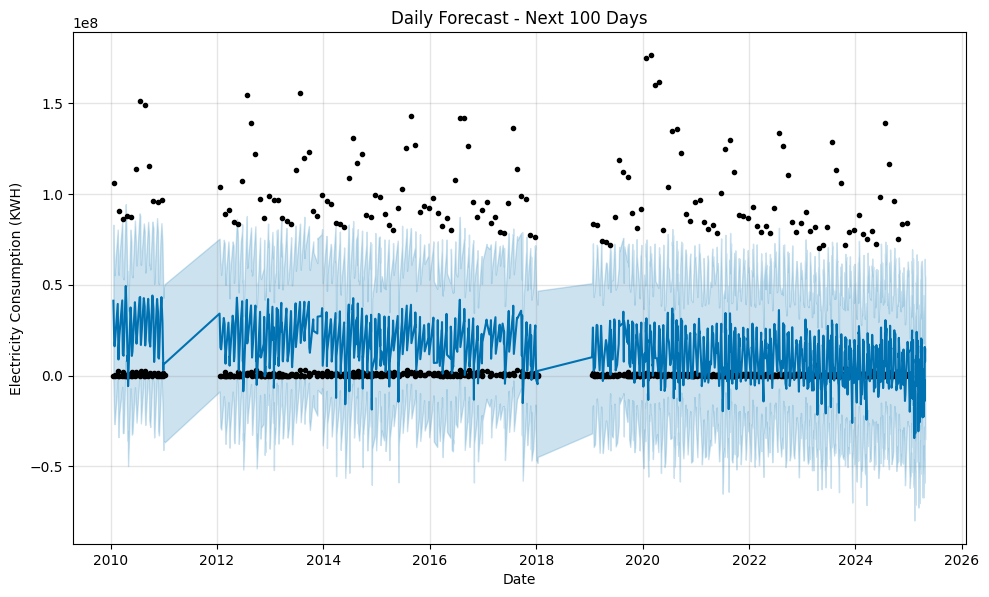

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/dc94zij5.json


100-Day Forecast - MAE: 23705586.26, MAPE: 474602087946606214119424.00%, R²: 0.14


DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/bge8wbig.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=29693', 'data', 'file=/tmp/tmps2xhvj79/dc94zij5.json', 'init=/tmp/tmps2xhvj79/bge8wbig.json', 'output', 'file=/tmp/tmps2xhvj79/prophet_model8h_y50yj/prophet_model-20250508225322.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:53:22 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:53:22 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


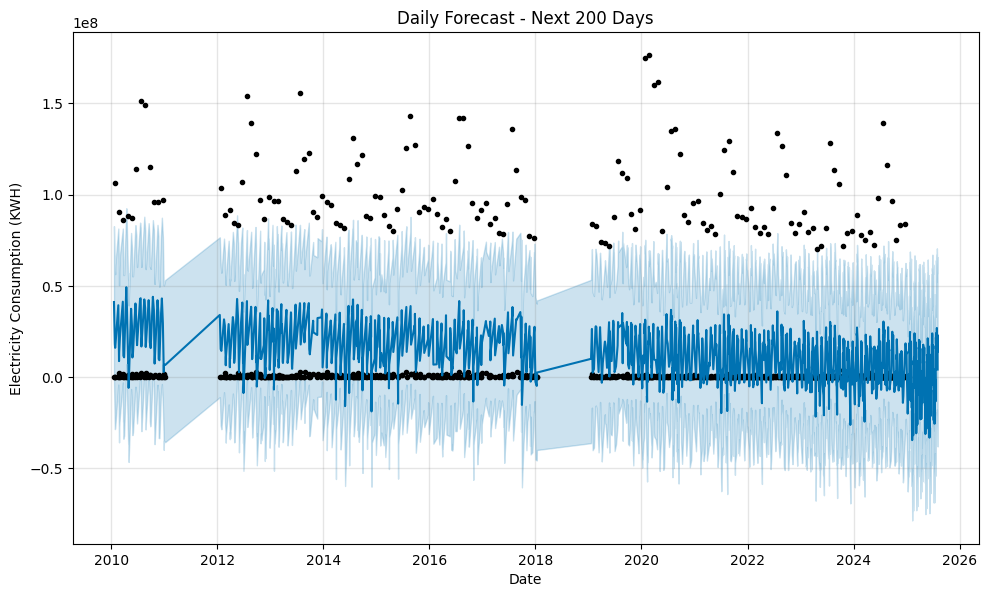

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/5ggor7it.json


200-Day Forecast - MAE: 23705586.26, MAPE: 474602087946606214119424.00%, R²: 0.14


DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/772bhj6r.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=16518', 'data', 'file=/tmp/tmps2xhvj79/5ggor7it.json', 'init=/tmp/tmps2xhvj79/772bhj6r.json', 'output', 'file=/tmp/tmps2xhvj79/prophet_modelgh_8tmd5/prophet_model-20250508225324.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:53:24 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:53:25 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


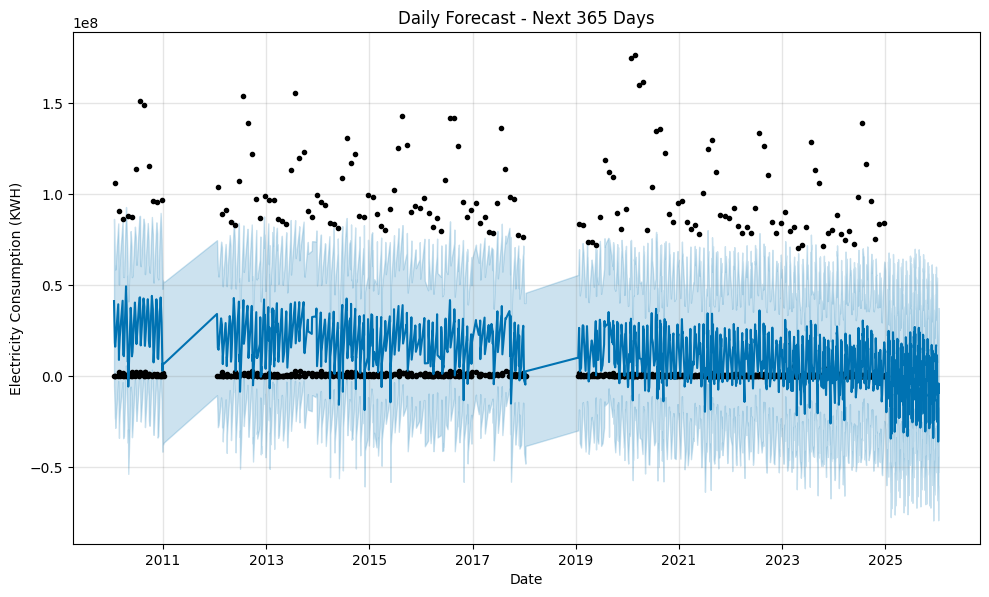

365-Day Forecast - MAE: 23705586.26, MAPE: 474602087946606214119424.00%, R²: 0.14


In [15]:
# Updated Daily Forecasts for 100, 200, 365 Days
def forecast_days(df, num_days):
    model = Prophet(
        growth='linear',
        seasonality_mode='additive',
        changepoint_prior_scale=0.1,
        n_changepoints=25
    )
    model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
    model.fit(df)

    future = model.make_future_dataframe(periods=num_days, freq='D')
    forecast = model.predict(future)

    df_eval = df.merge(forecast[['ds', 'yhat']], on='ds')
    mae = mean_absolute_error(df_eval['y'], df_eval['yhat'])
    mape = mean_absolute_percentage_error(df_eval['y'], df_eval['yhat'])
    r2 = r2_score(df_eval['y'], df_eval['yhat'])

    model.plot(forecast)
    plt.title(f"Daily Forecast - Next {num_days} Days")
    plt.xlabel("Date")
    plt.ylabel("Electricity Consumption (KWH)")
    plt.show()

    print(f"{num_days}-Day Forecast - MAE: {mae:.2f}, MAPE: {mape:.2%}, R²: {r2:.2f}")
    return forecast[['ds', 'yhat']]

# Apply to daily data
# Changed 'daily_df' to 'df_daily'
forecast_100d = forecast_days(df_daily, 100)
forecast_200d = forecast_days(df_daily, 200)
forecast_365d = forecast_days(df_daily, 365)

DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/4bngfhl9.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/c49jcowt.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=38033', 'data', 'file=/tmp/tmps2xhvj79/4bngfhl9.json', 'init=/tmp/tmps2xhvj79/c49jcowt.json', 'output', 'file=/tmp/tmps2xhvj79/prophet_modeleww13qr8/prophet_model-20250508225326.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:53:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


Running monthly Forecasts:

--- MONTHLY forecast for 1 steps ahead ---


22:53:26 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


MAE: 24031238.81
MAPE: inf%
R²: 0.04
             ds          yhat
1053 2025-02-01  8.019290e+06


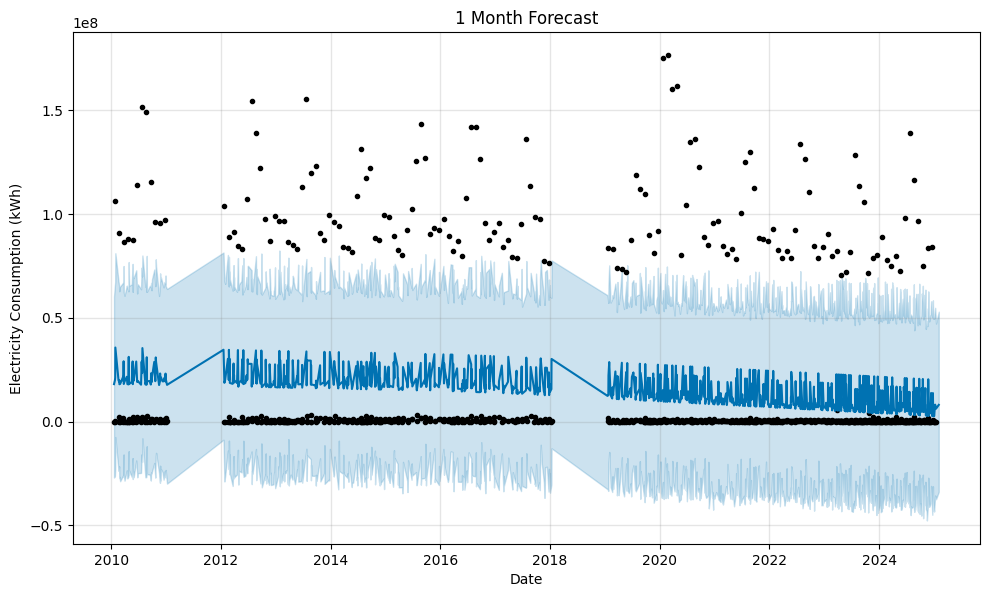

DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/zqe_2gny.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/nmr56kc9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=74375', 'data', 'file=/tmp/tmps2xhvj79/zqe_2gny.json', 'init=/tmp/tmps2xhvj79/nmr56kc9.json', 'output', 'file=/tmp/tmps2xhvj79/prophet_modeltidj3j34/prophet_model-20250508225327.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:53:27 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:53:27 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



--- MONTHLY forecast for 6 steps ahead ---
MAE: 24031238.81
MAPE: inf%
R²: 0.04
             ds          yhat
1053 2025-02-01  8.019290e+06
1054 2025-03-01  4.152594e+06
1055 2025-04-01  4.034388e+06
1056 2025-05-01  2.085071e+06
1057 2025-06-01  7.551461e+06
1058 2025-07-01  5.520382e+06


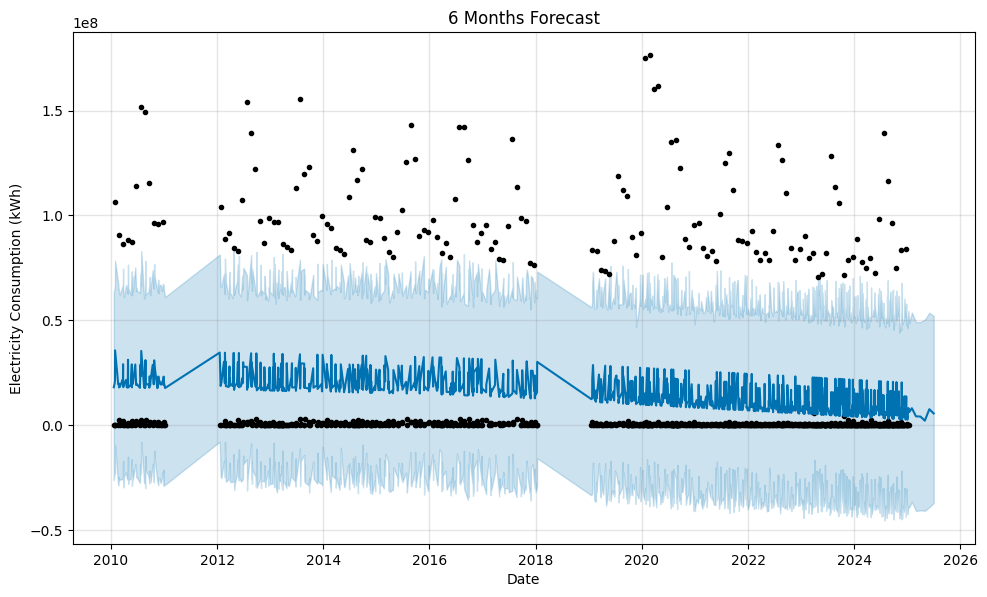

DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/igxsy9qm.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/3rx0c4va.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=99584', 'data', 'file=/tmp/tmps2xhvj79/igxsy9qm.json', 'init=/tmp/tmps2xhvj79/3rx0c4va.json', 'output', 'file=/tmp/tmps2xhvj79/prophet_model2altiaqd/prophet_model-20250508225327.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:53:27 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:53:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



--- MONTHLY forecast for 9 steps ahead ---
MAE: 24031238.81
MAPE: inf%
R²: 0.04
             ds          yhat
1053 2025-02-01  8.019290e+06
1054 2025-03-01  4.152594e+06
1055 2025-04-01  4.034388e+06
1056 2025-05-01  2.085071e+06
1057 2025-06-01  7.551461e+06
1058 2025-07-01  5.520382e+06
1059 2025-08-01  4.840451e+06
1060 2025-09-01  3.332692e+06
1061 2025-10-01  1.913116e+07


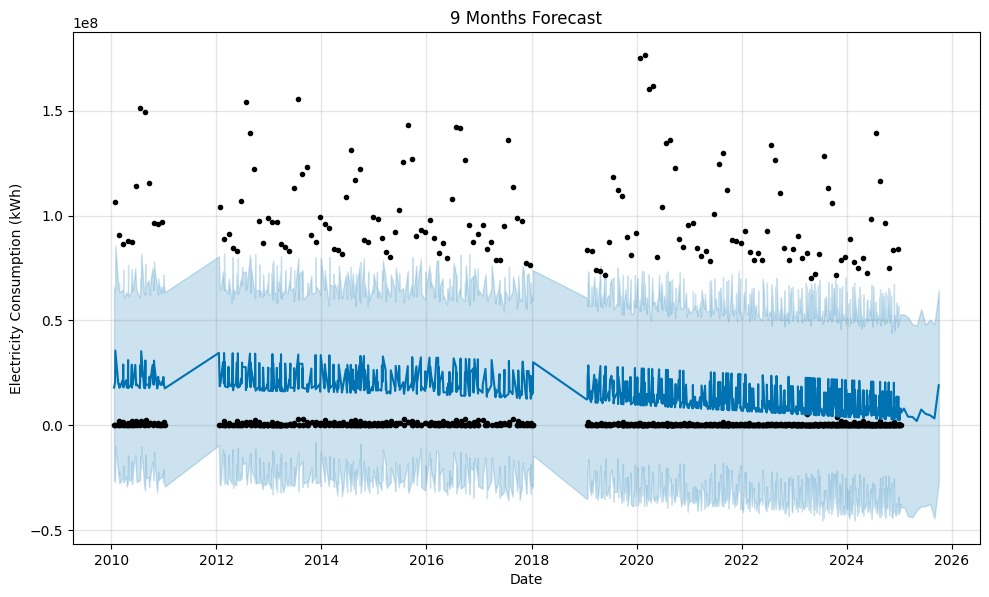

In [16]:
print("Running monthly Forecasts:")
build_and_forecast(df_daily)

INFO:prophet:n_changepoints greater than number of observations. Using 11.
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/6in3eo1e.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/1qk9tyhl.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=52667', 'data', 'file=/tmp/tmps2xhvj79/6in3eo1e.json', 'init=/tmp/tmps2xhvj79/1qk9tyhl.json', 'output', 'file=/tmp/tmps2xhvj79/prophet_modeltddzs_9p/prophet_model-20250508225328.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
22:53:28 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:53:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Running Yearly Forecasts:

--- YEARLY forecast for 1 steps ahead ---
MAE: 5264545.61
MAPE: inf%
R²: 0.22
           ds          yhat
16 2026-01-01  7.610802e+06


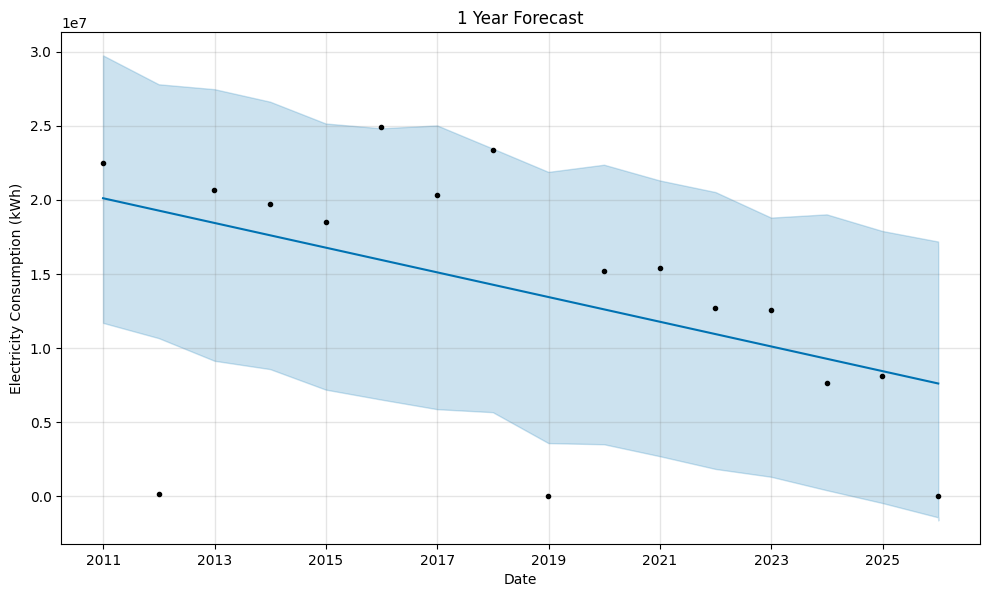

INFO:prophet:n_changepoints greater than number of observations. Using 11.
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/v2cqobyh.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/b1oe3bin.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=86891', 'data', 'file=/tmp/tmps2xhvj79/v2cqobyh.json', 'init=/tmp/tmps2xhvj79/b1oe3bin.json', 'output', 'file=/tmp/tmps2xhvj79/prophet_modelwjn77767/prophet_model-20250508225328.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
22:53:28 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:53:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



--- YEARLY forecast for 10 steps ahead ---
MAE: 5264545.61
MAPE: inf%
R²: 0.22
           ds          yhat
16 2026-01-01  7.610802e+06
17 2027-01-01  6.778476e+06
18 2028-01-01  5.946151e+06
19 2029-01-01  5.111545e+06
20 2030-01-01  4.279219e+06
21 2031-01-01  3.446894e+06
22 2032-01-01  2.614569e+06
23 2033-01-01  1.779963e+06
24 2034-01-01  9.476373e+05
25 2035-01-01  1.153119e+05


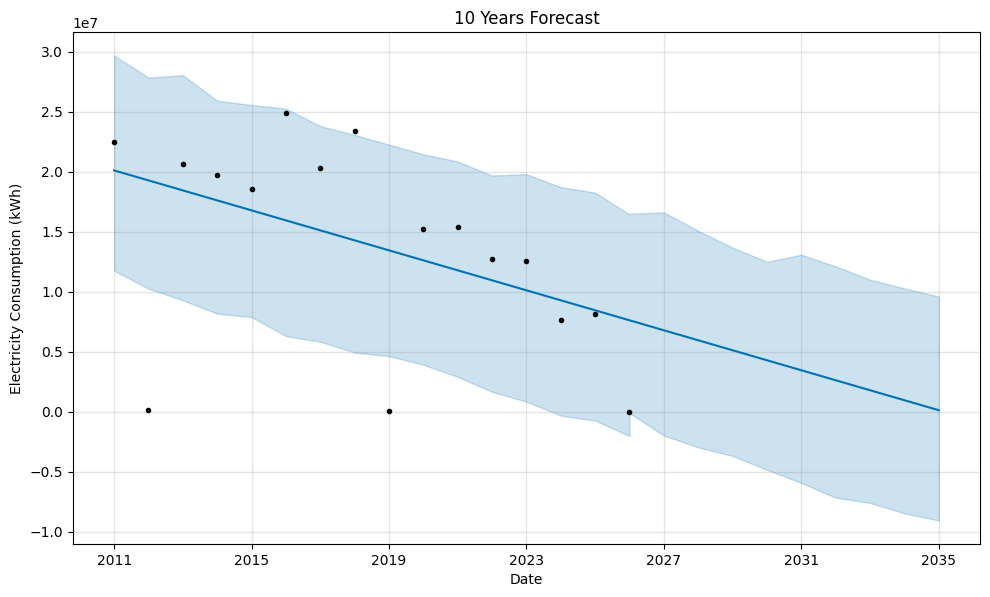

INFO:prophet:n_changepoints greater than number of observations. Using 11.
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/xx6hbol0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/0aquwmst.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=34588', 'data', 'file=/tmp/tmps2xhvj79/xx6hbol0.json', 'init=/tmp/tmps2xhvj79/0aquwmst.json', 'output', 'file=/tmp/tmps2xhvj79/prophet_model6l4jp_pd/prophet_model-20250508225329.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
22:53:29 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:53:29 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



--- YEARLY forecast for 20 steps ahead ---
MAE: 5264545.61
MAPE: inf%
R²: 0.22
           ds          yhat
16 2026-01-01  7.610802e+06
17 2027-01-01  6.778476e+06
18 2028-01-01  5.946151e+06
19 2029-01-01  5.111545e+06
20 2030-01-01  4.279219e+06
21 2031-01-01  3.446894e+06
22 2032-01-01  2.614569e+06
23 2033-01-01  1.779963e+06
24 2034-01-01  9.476373e+05
25 2035-01-01  1.153119e+05
26 2036-01-01 -7.170136e+05
27 2037-01-01 -1.551619e+06
28 2038-01-01 -2.383945e+06
29 2039-01-01 -3.216270e+06
30 2040-01-01 -4.048596e+06
31 2041-01-01 -4.883201e+06
32 2042-01-01 -5.715527e+06
33 2043-01-01 -6.547852e+06
34 2044-01-01 -7.380178e+06
35 2045-01-01 -8.214784e+06


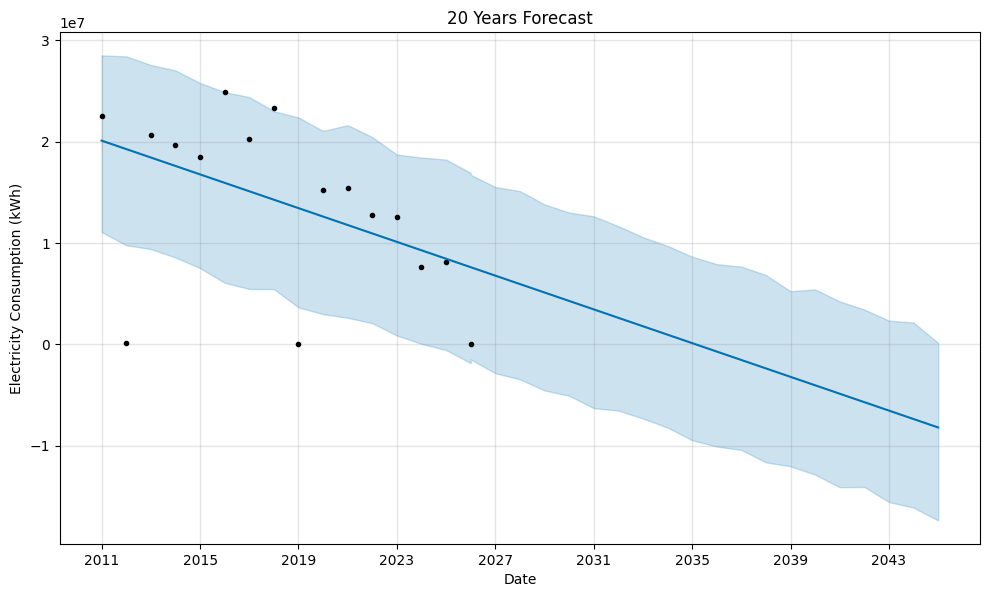

In [17]:
# Print and run Yearly Forecasts
print("Running Yearly Forecasts:")
build_and_forecast(df_yearly)


<ipython-input-18-423b5a840731>:9: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Electric_Consumption_And_Cost__2010_-_Feb_2025__20250506.csv")
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/gtwjv7wm.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/0a2316jq.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=28004', 'data', 'file=/tmp/tmps2xhvj79/gtwjv7wm.json', 'init=/tmp/tmps2xhvj79/0a2316jq.json', 'output', 'file=/tmp/tmps2xhvj79/prophet_modelkzwnjmi2/prophet_model-20250508225333.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:53:33 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:53:33 - cmdstanpy


--- Forecast for BRONX ---
MAE: 5961354.44, MAPE: 42104385321162640457728.00%, R^2: 0.61


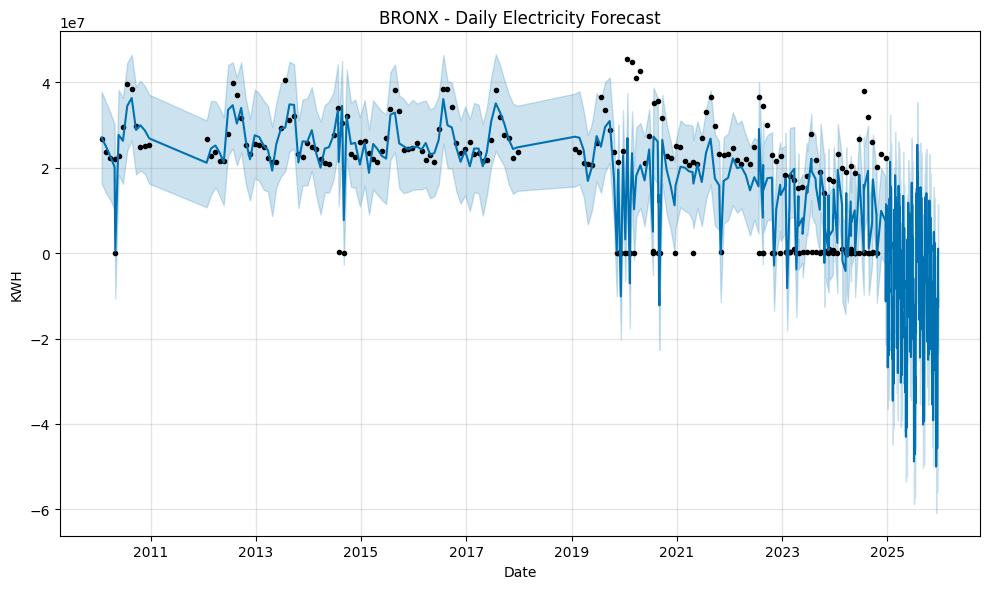

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/caom7kjd.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/kx4_a9wz.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=84825', 'data', 'file=/tmp/tmps2xhvj79/caom7kjd.json', 'init=/tmp/tmps2xhvj79/kx4_a9wz.json', 'output', 'file=/tmp/tmps2xhvj79/prophet_modelrhqnazzh/prophet_model-20250508225333.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:53:33 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:53:33 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



--- Forecast for BROOKLYN ---
MAE: 8725664.13, MAPE: 430229435688464425156608.00%, R^2: 0.52


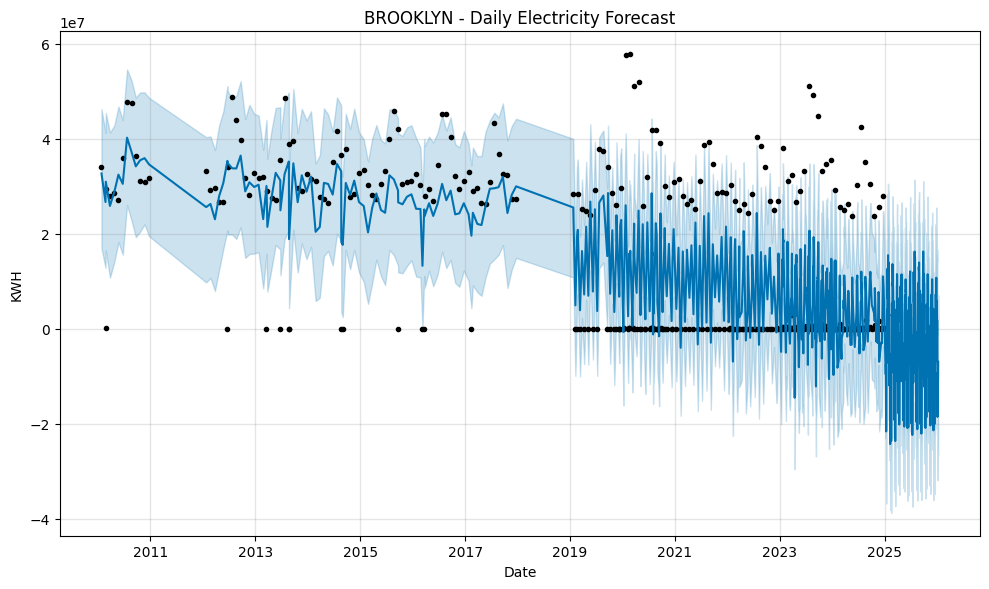

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/e1nvc6p1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/_r0_17k0.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=57201', 'data', 'file=/tmp/tmps2xhvj79/e1nvc6p1.json', 'init=/tmp/tmps2xhvj79/_r0_17k0.json', 'output', 'file=/tmp/tmps2xhvj79/prophet_modellahz87cv/prophet_model-20250508225334.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']



--- Forecast for MANHATTAN ---


22:53:34 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:53:34 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


MAE: 8894145.13, MAPE: 350150871635730477613056.00%, R^2: 0.49


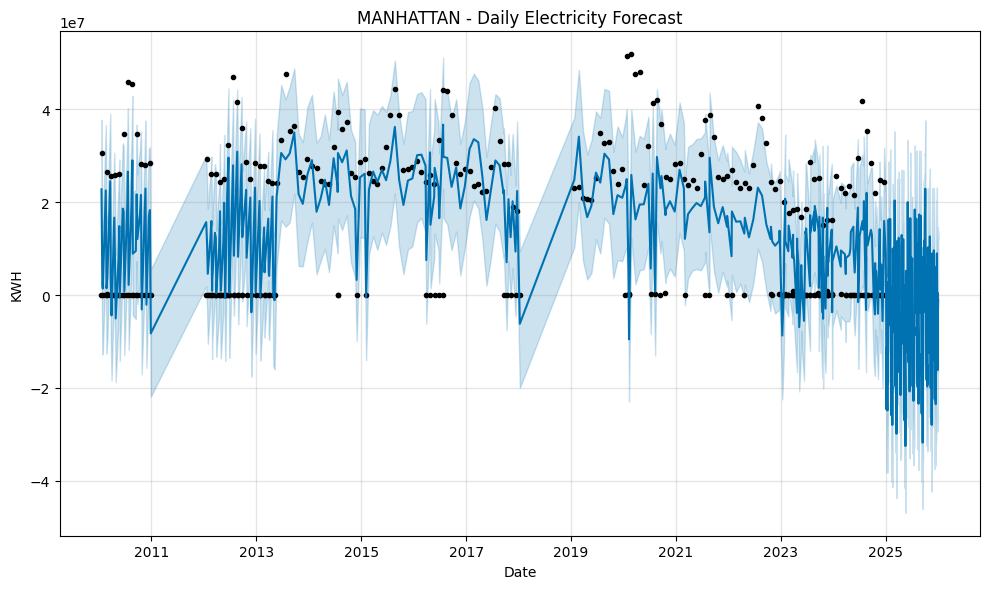

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/_ti7kcrn.json



--- Forecast for QUEENS ---


DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/3c4tivfs.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=76345', 'data', 'file=/tmp/tmps2xhvj79/_ti7kcrn.json', 'init=/tmp/tmps2xhvj79/3c4tivfs.json', 'output', 'file=/tmp/tmps2xhvj79/prophet_modelrrztm10b/prophet_model-20250508225335.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:53:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:53:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


MAE: 2174080.18, MAPE: 35438892283190017261568.00%, R^2: 0.22


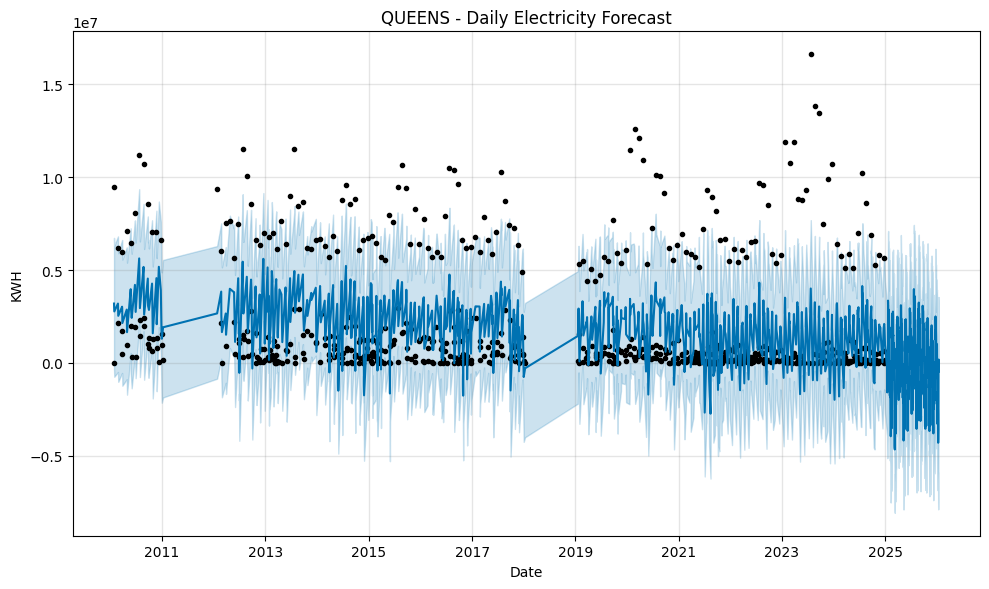

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/99y0ecgc.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/u3tfniny.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=86073', 'data', 'file=/tmp/tmps2xhvj79/99y0ecgc.json', 'init=/tmp/tmps2xhvj79/u3tfniny.json', 'output', 'file=/tmp/tmps2xhvj79/prophet_model3a8n075c/prophet_model-20250508225336.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:53:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing



--- Forecast for STATEN ISLAND ---


22:53:36 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


MAE: 349863.54, MAPE: 36775335528218791936.00%, R^2: 0.65


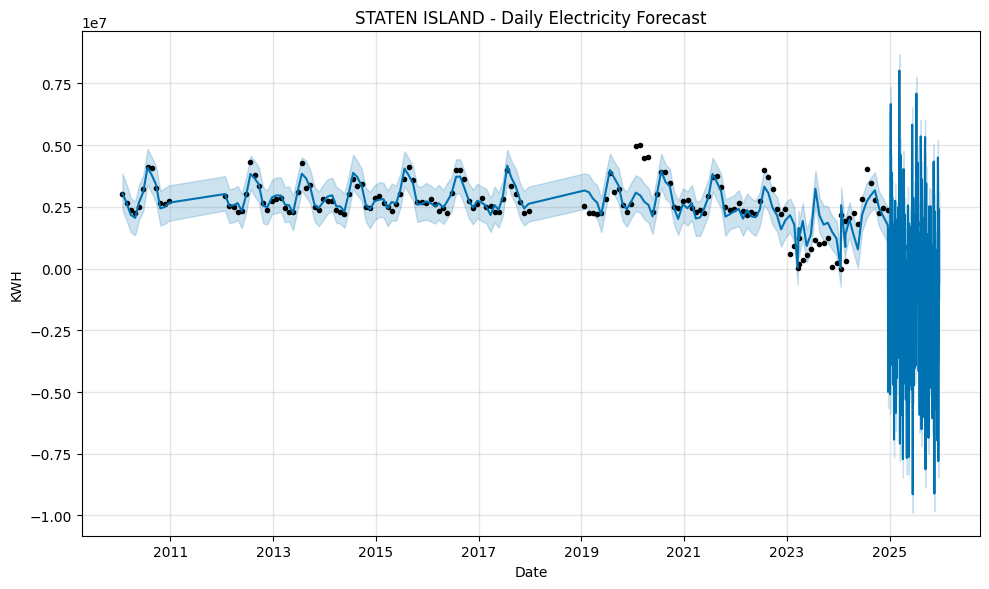

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/if8qwk70.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/ev_b1wwc.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=5506', 'data', 'file=/tmp/tmps2xhvj79/if8qwk70.json', 'init=/tmp/tmps2xhvj79/ev_b1wwc.json', 'output', 'file=/tmp/tmps2xhvj79/prophet_modelt6tes2rg/prophet_model-20250508225337.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:53:37 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:53:37 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



--- Forecast for NON DEVELOPMENT FACILITY ---
MAE: 344209.77, MAPE: 5915727247444019249152.00%, R^2: 0.65


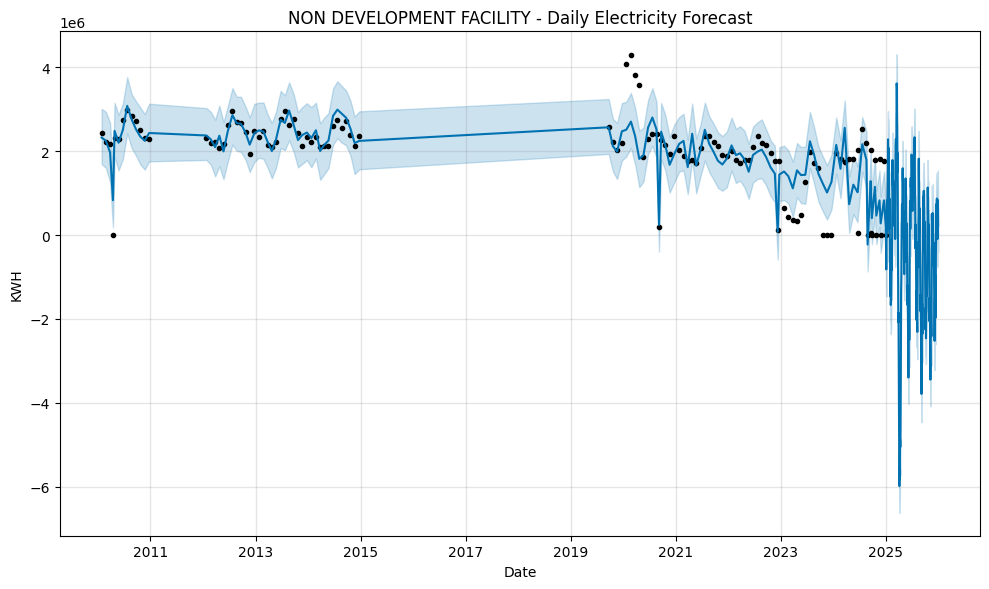

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/3kyzhjq8.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmps2xhvj79/5lwxr4er.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=73184', 'data', 'file=/tmp/tmps2xhvj79/3kyzhjq8.json', 'init=/tmp/tmps2xhvj79/5lwxr4er.json', 'output', 'file=/tmp/tmps2xhvj79/prophet_modelyw87ghj6/prophet_model-20250508225338.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:53:38 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:53:38 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



--- Forecast for FHA ---
MAE: 92045.87, MAPE: 72399855290186907648.00%, R^2: 0.34


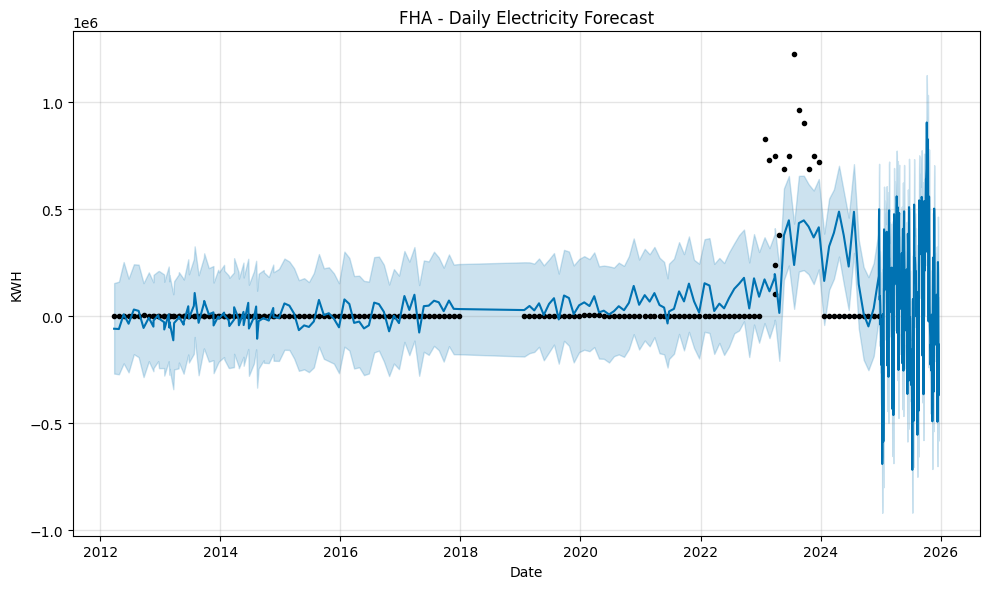

In [18]:
# Per-Borough Electricity Forecast (Daily)

import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# Ensure date and numeric fields are parsed correctly
df = pd.read_csv("Electric_Consumption_And_Cost__2010_-_Feb_2025__20250506.csv")
df['Service End Date'] = pd.to_datetime(df['Service End Date'], errors='coerce')
df['Consumption (KWH)'] = pd.to_numeric(df['Consumption (KWH)'], errors='coerce')

# Drop NA
df = df[['Borough', 'Service End Date', 'Consumption (KWH)']].dropna()

boroughs = df['Borough'].unique()
for borough in boroughs:
    print(f"\n--- Forecast for {borough} ---")
    boro_df = df[df['Borough'] == borough]
    boro_df = boro_df.groupby('Service End Date')['Consumption (KWH)'].sum().reset_index()
    boro_df.columns = ['ds', 'y']
    boro_df = boro_df.sort_values('ds').reset_index(drop=True)

    # Prophet model
    model = Prophet(growth='linear', changepoint_prior_scale=0.1, n_changepoints=20)
    model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
    model.fit(boro_df)

    # Forecast 365 days
    future = model.make_future_dataframe(periods=365)
    forecast = model.predict(future)

    # Evaluation
    merged = boro_df.merge(forecast[['ds', 'yhat']], on='ds')
    mae = mean_absolute_error(merged['y'], merged['yhat'])
    mape = mean_absolute_percentage_error(merged['y'], merged['yhat'])
    r2 = r2_score(merged['y'], merged['yhat'])

    print(f"MAE: {mae:.2f}, MAPE: {mape:.2%}, R^2: {r2:.2f}")

    # Plot
    fig = model.plot(forecast)
    plt.title(f"{borough} - Daily Electricity Forecast")
    plt.xlabel("Date")
    plt.ylabel("KWH")
    plt.tight_layout()
    plt.show()

In [ ]:
# Prophet with Logistic Growth
from prophet import Prophet
import numpy as np

# Set capacity cap for logistic growth
df_logistic = df_daily.copy()
df_logistic['cap'] = df_logistic['y'].max() * 1.2

model_logistic = Prophet(growth='logistic')
model_logistic.add_seasonality(name='monthly', period=30.5, fourier_order=5)
model_logistic.fit(df_logistic)

future_logistic = model_logistic.make_future_dataframe(periods=365)
future_logistic['cap'] = df_logistic['cap'].iloc[0]  # constant cap
forecast_logistic = model_logistic.predict(future_logistic)

fig = model_logistic.plot(forecast_logistic)
plt.title('Logistic Growth Forecast - 365 Days')
plt.xlabel('Date')
plt.ylabel('Electricity Consumption (KWH)')
plt.grid(True)
plt.show()

In [ ]:
# Flat Classifier using Linear Regression + Thresholding
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Flatten to tabular: using lag features as input (example transformation)
df_flat = df_daily.copy()
df_flat['y_shifted'] = df_flat['y'].shift(-1)
df_flat.dropna(inplace=True)
X = df_flat[['y']]
y = (df_flat['y_shifted'] > df_flat['y_shifted'].mean()).astype(int)  # classify above/below avg

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
flat_model = LinearRegression()
flat_model.fit(X_train, y_train)
y_pred_flat = flat_model.predict(X_test)
y_pred_flat_class = [1 if y >= 0.5 else 0 for y in y_pred_flat]

print('Flat Classifier Results')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_flat_class))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_flat_class))
print('Accuracy:', accuracy_score(y_test, y_pred_flat_class))

In [ ]:
# Comparison Table for All Models
import pandas as pd

# Recalculate metrics for linear
merged_linear = df_daily.merge(forecast_365d[["ds", "yhat"]], on="ds")
mae_linear = mean_absolute_error(merged_linear['y'], merged_linear['yhat'])
mape_linear = mean_absolute_percentage_error(merged_linear['y'], merged_linear['yhat'])
r2_linear = r2_score(merged_linear['y'], merged_linear['yhat'])

# Recalculate metrics for logistic
merged_logistic = df_daily.merge(forecast_logistic[['ds', 'yhat']], on='ds')
mae_logistic = mean_absolute_error(merged_logistic['y'], merged_logistic['yhat'])
mape_logistic = mean_absolute_percentage_error(merged_logistic['y'], merged_logistic['yhat'])
r2_logistic = r2_score(merged_logistic['y'], merged_logistic['yhat'])

# Accuracy for flat classifier already computed
flat_accuracy = accuracy_score(y_test, y_pred_flat_class)

# Summary table
summary_df = pd.DataFrame({
    'Model': ['Prophet Linear', 'Prophet Logistic', 'Flat Classifier'],
    'MAE': [mae_linear, mae_logistic, 'N/A'],
    'MAPE': [mape_linear, mape_logistic, 'N/A'],
    'R2': [r2_linear, r2_logistic, 'N/A'],
    'Accuracy': ['N/A', 'N/A', flat_accuracy]
})

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.table import Table

summary_df_display = summary_df.fillna('-')
print(summary_df_display)

plt.figure(figsize=(10, 1))
plt.axis('off')
tbl = plt.table(cellText=summary_df_display.values, colLabels=summary_df_display.columns, loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2)
plt.title("Model Comparison Table")
plt.show()

In [ ]:
# Logistic Growth Forecasts for Days, Months, and Years
def detect_freq(df):
    delta = (df['ds'].iloc[1] - df['ds'].iloc[0]).days
    if delta == 1:
        return 'daily', [100, 200, 365], 'D', 30
    elif delta <= 31:
        return 'monthly', [1, 6, 9], 'MS', 12
    else:
        return 'yearly', [1, 10, 20], 'YS', 1

def forecast_logistic_multi(df):
    freq, future_periods, pd_freq, season_period = detect_freq(df)
    df_log = df.copy()
    df_log['cap'] = df['y'].max() * 1.2

    for p in future_periods:
        print(f"\n--- Logistic {freq.upper()} forecast for {p} steps ---")
        model = Prophet(growth='logistic')
        model.add_seasonality(name='custom', period=season_period, fourier_order=5)
        model.fit(df_log)

        future = model.make_future_dataframe(periods=p, freq=pd_freq)
        future['cap'] = df_log['cap'].iloc[0]
        forecast = model.predict(future)

        fig = model.plot(forecast)
        plt.title(f"Logistic {freq.capitalize()} Forecast - Next {p} Steps")
        plt.xlabel('Date')
        plt.ylabel('Electricity Consumption (KWH)')
        plt.grid(True)
        plt.show()

# Run on daily, monthly, and yearly data
forecast_logistic_multi(df_daily)
forecast_logistic_multi(df_monthly)
forecast_logistic_multi(df_yearly)

In [ ]:
# Flat Classifier for Daily, Monthly, Yearly
def flat_classifier_multi(df):
    df_flat = df.copy()
    df_flat['y_shifted'] = df_flat['y'].shift(-1)
    df_flat.dropna(inplace=True)
    X = df_flat[['y']]
    y = (df_flat['y_shifted'] > df_flat['y_shifted'].mean()).astype(int)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_class = [1 if p >= 0.5 else 0 for p in y_pred]

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_class))
    print("Classification Report:")
    print(classification_report(y_test, y_pred_class))
    print("Accuracy:", accuracy_score(y_test, y_pred_class))

# Run on all time granularities
flat_classifier_multi(df_daily)
flat_classifier_multi(df_monthly)
flat_classifier_multi(df_yearly)